#### Reload Best Model from Checkpoint & t-SNE Visualization

This section can be run from a fresh kernel (after SSH disconnect). It reloads all the necessary definitions, loads the saved best model checkpoint, collects latent embeddings from the validation and test sets, and produces t-SNE plots coloured by binding label.

In [1]:
# ── Self-contained setup: imports, paths, model classes, data loaders ──

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE

from peft import get_peft_model, LoraConfig, TaskType
from peft.tuners.lora import LoraConfig, LoraModel

# ESM imports
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinTensor
from esm.models.esmc import _BatchedESMProteinTensor

import gc
import re
import shutil
import subprocess

# Tokenizer imports
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers import normalizers
from tokenizers.normalizers import NFD, Lowercase, StripAccents
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordPieceTrainer
from tokenizers import decoders

import pandas as pd

from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import Dataset, DataLoader

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ---- Paths ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

project_root = Path("/home/natasha/multimodal_model")
checkpoints_dir = project_root / "models" / "checkpoints"
embeddings_dir  = project_root / "models" / "embeddings"
figure_dir      = project_root / "models" / "figures"
EMBED_ROOT      = embeddings_dir / "no_boltz"

print(f"Device: {device}")
print(f"Checkpoint dir: {checkpoints_dir}")
print(f"Embed root: {EMBED_ROOT}")


# ---- Model class definitions (copied from earlier cells for self-contained reload) ----

eps = 1e-8

class ESMProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_max):
        super().__init__()
        self.D   = D
        self.rL  = rL
        self.rD  = rD
        self.d   = d
        self.L_max = L_max

        self.B_c = nn.Parameter(torch.empty(D, rD))
        nn.init.xavier_uniform_(self.B_c)

        self.A_c = nn.Parameter(torch.empty(L_max, rL))
        nn.init.xavier_uniform_(self.A_c)

        self.H_c = nn.Parameter(torch.empty(rL * rD, d))
        nn.init.xavier_uniform_(self.H_c)

        self.expander = nn.Sequential(
            nn.Linear(d, d),
            nn.BatchNorm1d(d),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d, d),
        )

    def forward(self, emb, mask):
        device = emb.device
        B, L_pad, D = emb.shape
        assert D == self.D

        L_true = mask.sum(dim=1)
        z_list = []

        for b in range(B):
            Lb = int(L_true[b].item())
            if Lb == 0:
                z_list.append(torch.zeros(self.d, device=device))
                continue

            Xb = emb[b, :Lb, :]
            mb = mask[b, :Lb].unsqueeze(-1).float()
            Xb = Xb * mb

            Yb = Xb @ self.B_c
            A_pos = self.A_c[:Lb, :]
            Ub = A_pos.T @ Yb
            Ub_flat = Ub.reshape(-1)
            z_b = Ub_flat @ self.H_c
            z_list.append(z_b)

        z = torch.stack(z_list, dim=0)
        z = self.expander(z)
        return z


class PMHCProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_P_max, L_H_max, R_PH=0.7):
        super().__init__()
        self.D    = D
        self.rL   = rL
        self.rD   = rD
        self.d    = d
        self.R_PH = R_PH

        d_P = int(round(R_PH * d))
        d_H = d - d_P
        assert d_P > 0 and d_H > 0

        self.d_P = d_P
        self.d_H = d_H

        self.pep_encoder = ESMProjectionHead(D, rL, rD, d_P, L_P_max)
        self.hla_encoder = ESMProjectionHead(D, rL, rD, d_H, L_H_max)

    def forward(self, emb_P, mask_P, emb_H, mask_H):
        zP = self.pep_encoder(emb_P, mask_P)
        zH = self.hla_encoder(emb_H, mask_H)
        zPH = torch.cat([zP, zH], dim=-1)
        return zPH


# ---- Dataset ----

class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


# ---- Data loaders ----

train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")
val_dataset   = ShardedBatchTripletDataset(EMBED_ROOT / "val")
test_dataset  = ShardedBatchTripletDataset(EMBED_ROOT / "test")

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=0, collate_fn=lambda x: x[0],
)

test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False,
    num_workers=0, collate_fn=lambda x: x[0],
)

# ---- Global max lengths (from train set) ----
sample = train_dataset[0]
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D       = sample["emb_T"].shape[2]

print(f"D={D}, L_T_max={L_T_max}, L_P_max={L_P_max}, L_H_max={L_H_max}")
print(f"Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda
Checkpoint dir: /home/natasha/multimodal_model/models/checkpoints
Embed root: /home/natasha/multimodal_model/models/embeddings/no_boltz
D=960, L_T_max=249, L_P_max=26, L_H_max=368
Val batches: 493, Test batches: 523


In [5]:
# ── Load best checkpoint and instantiate projection heads ──

ckpt_path = checkpoints_dir / "best_baseline_projection_model.pt"
checkpoint = torch.load(ckpt_path, map_location="cpu")

cfg = checkpoint["best_config"]
best_threshold = checkpoint["best_threshold"]

print("Best config:", cfg)
print("Best threshold:", best_threshold)
print("Best epoch:", checkpoint["best_epoch"])
print("Best val metrics:", checkpoint["best_val_metrics"])

# Instantiate projection heads with the saved hyperparameters
rL   = cfg["rL"]
rD   = cfg["rD"]
d    = cfg["d"]
R_PH = cfg.get("R_PH", 0.7)

tcr_projection = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
pmhc_projection = PMHCProjectionHead(
    D, rL, rD, d,
    L_P_max=L_P_max,
    L_H_max=L_H_max,
    R_PH=R_PH,
).to(device)

# Load saved state dicts
tcr_projection.load_state_dict(checkpoint["tcr_projection_state_dict"])
pmhc_projection.load_state_dict(checkpoint["pmhc_projection_state_dict"])

tcr_projection.eval()
pmhc_projection.eval()

print("\nProjection heads loaded and set to eval mode.")

Best config: {'rL': 8, 'rD': 16, 'd': 128, 'R_PH': 0.7, 'alpha': 25.0, 'beta': 25.0, 'delta': 1.0, 'gamma_var': 1.0, 'lr_tcr': 0.0001, 'lr_pmhc': 0.0001, 'weight_decay': 0.01, 'num_epochs': 20, 'patience': 5, 'loss_type': 'vicreg_mse'}
Best threshold: -1.8508262634277344
Best epoch: 14
Best val metrics: {'auroc': 0.7260388374485597, 'auprc': 0.7326854342307765, 'threshold': -1.8508262634277344, 'f1': 0.6863483257380623, 'accuracy': 0.598630831643002, 'precision': 0.558169513374154, 'recall': 0.8909465020576132}

Projection heads loaded and set to eval mode.


In [6]:
# ── Collect latent embeddings (zT, zPH) from a loader ──

@torch.no_grad()
def collect_embeddings(loader, tcr_projection, pmhc_projection, device):
    """
    Run all batches through the projection heads and collect
    zT (TCR embedding), zPH (pMHC embedding), and binding labels.
    """
    tcr_projection.eval()
    pmhc_projection.eval()

    all_zT  = []
    all_zPH = []
    all_labels = []

    for batch in loader:
        emb_T  = batch["emb_T"].to(device)
        mask_T = batch["mask_T"].to(device)
        emb_P  = batch["emb_P"].to(device)
        mask_P = batch["mask_P"].to(device)
        emb_H  = batch["emb_H"].to(device)
        mask_H = batch["mask_H"].to(device)

        zT  = tcr_projection(emb_T, mask_T)
        zPH = pmhc_projection(emb_P, mask_P, emb_H, mask_H)

        all_zT.append(zT.cpu().numpy())
        all_zPH.append(zPH.cpu().numpy())

        labels = batch["binding_flag"]
        if torch.is_tensor(labels):
            labels = labels.cpu().numpy()
        else:
            labels = np.array(labels)
        all_labels.append(labels)

    return {
        "zT":     np.concatenate(all_zT),
        "zPH":    np.concatenate(all_zPH),
        "labels": np.concatenate(all_labels).astype(int),
    }


print("Collecting validation embeddings...")
val_embs = collect_embeddings(val_loader, tcr_projection, pmhc_projection, device)
print(f"  Val: {val_embs['zT'].shape[0]} samples, zT shape={val_embs['zT'].shape}, zPH shape={val_embs['zPH'].shape}")

print("Collecting test embeddings...")
test_embs = collect_embeddings(test_loader, tcr_projection, pmhc_projection, device)
print(f"  Test: {test_embs['zT'].shape[0]} samples, zT shape={test_embs['zT'].shape}, zPH shape={test_embs['zPH'].shape}")

  Val: 3944 samples, zT shape=(3944, 128), zPH shape=(3944, 128)
  Test: 4182 samples, zT shape=(4182, 128), zPH shape=(4182, 128)


Running t-SNE on validation set...
Running t-SNE on test set...
Figure saved to /home/natasha/multimodal_model/models/figures/tsne_vicreg_mse_val_test.png


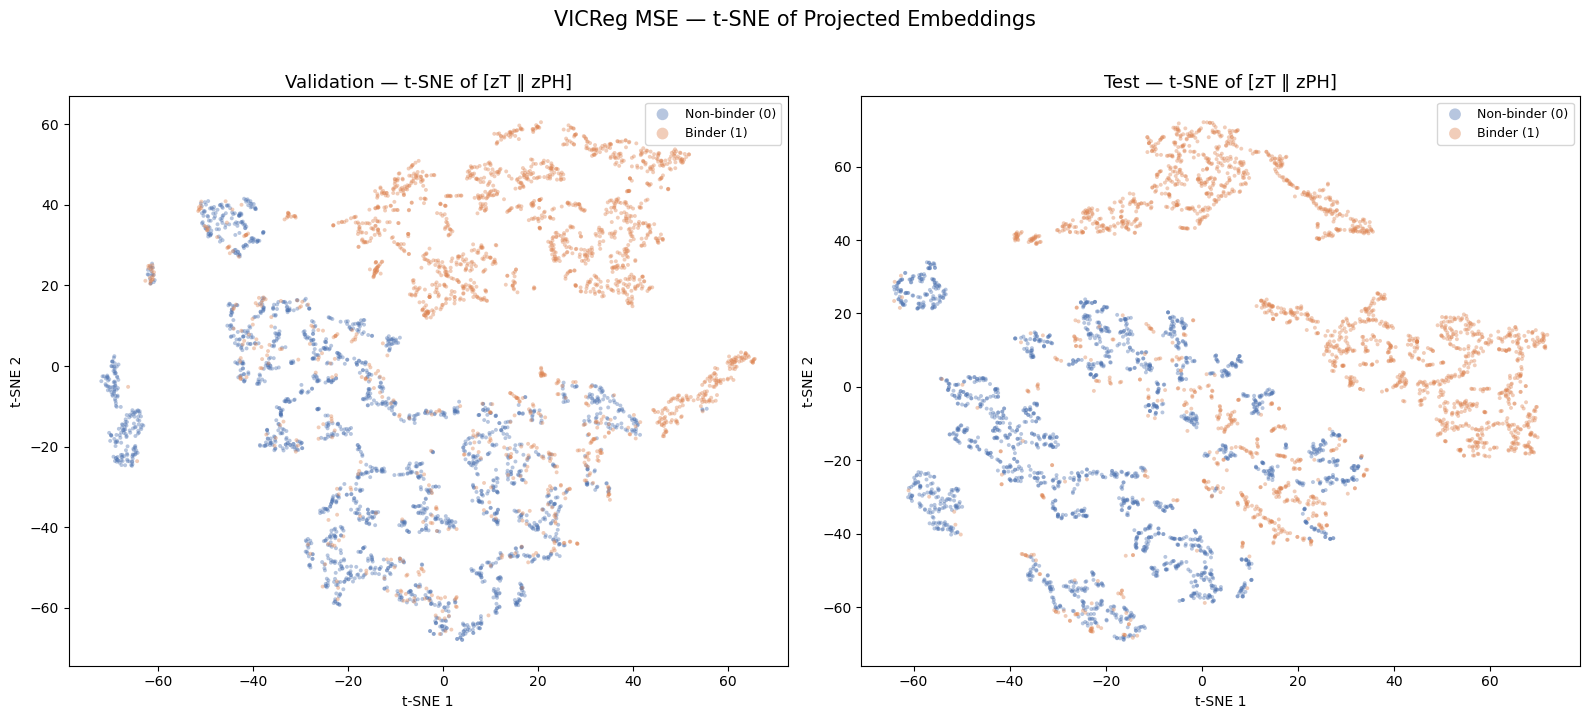

In [7]:
# ── t-SNE visualisation of joint [zT ‖ zPH] embeddings ──
# Concatenate TCR and pMHC embeddings into a single vector per sample,
# then run t-SNE and colour by binding label.

def run_tsne_and_plot(embs_dict, split_name, ax, perplexity=30, random_state=42):
    """
    embs_dict: dict with 'zT', 'zPH', 'labels'
    """
    # Concatenate TCR and pMHC latent vectors
    joint = np.concatenate([embs_dict["zT"], embs_dict["zPH"]], axis=1)
    labels = embs_dict["labels"]

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
    )
    coords = tsne.fit_transform(joint)

    neg_mask = labels == 0
    pos_mask = labels == 1

    ax.scatter(
        coords[neg_mask, 0], coords[neg_mask, 1],
        c="#4C72B0", label="Non-binder (0)", alpha=0.4, s=8, edgecolors="none",
    )
    ax.scatter(
        coords[pos_mask, 0], coords[pos_mask, 1],
        c="#DD8452", label="Binder (1)", alpha=0.4, s=8, edgecolors="none",
    )

    ax.set_title(f"{split_name} — t-SNE of [zT ‖ zPH]", fontsize=13)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc="best", fontsize=9, markerscale=3)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

print("Running t-SNE on validation set...")
run_tsne_and_plot(val_embs, "Validation", axes[0])

print("Running t-SNE on test set...")
run_tsne_and_plot(test_embs, "Test", axes[1])

fig.suptitle("VICReg MSE — t-SNE of Projected Embeddings", fontsize=15, y=1.02)
fig.tight_layout()

# Save figure
save_path = figure_dir / "tsne_vicreg_mse_val_test.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to {save_path}")

plt.show()

Running t-SNE on validation TCR embeddings (zT)...


Running t-SNE on test TCR embeddings (zT)...
Figure saved to /home/natasha/multimodal_model/models/figures/tsne_vicreg_mse_zT_val_test.png


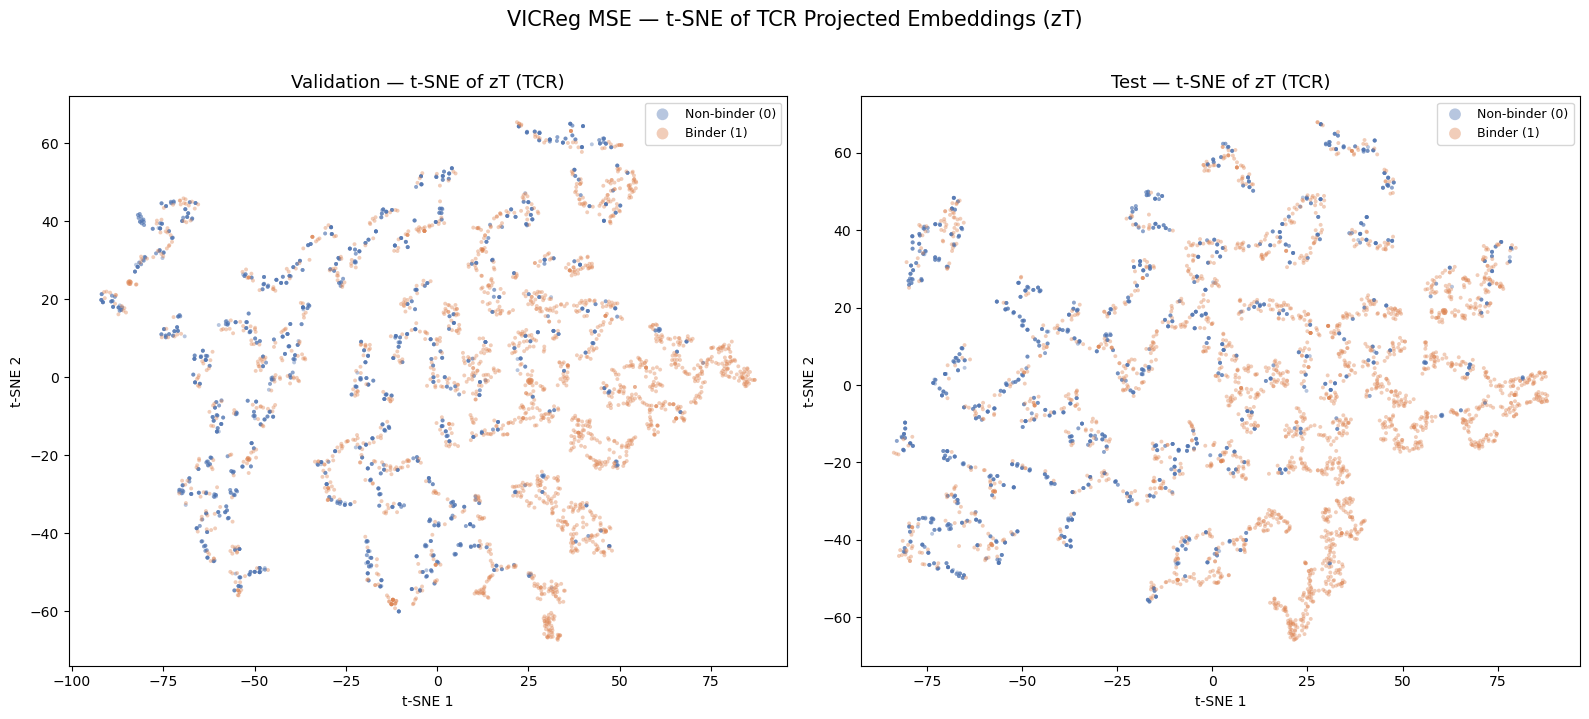

Running t-SNE on validation pMHC embeddings (zPH)...
Running t-SNE on test pMHC embeddings (zPH)...
Figure saved to /home/natasha/multimodal_model/models/figures/tsne_vicreg_mse_zPH_val_test.png


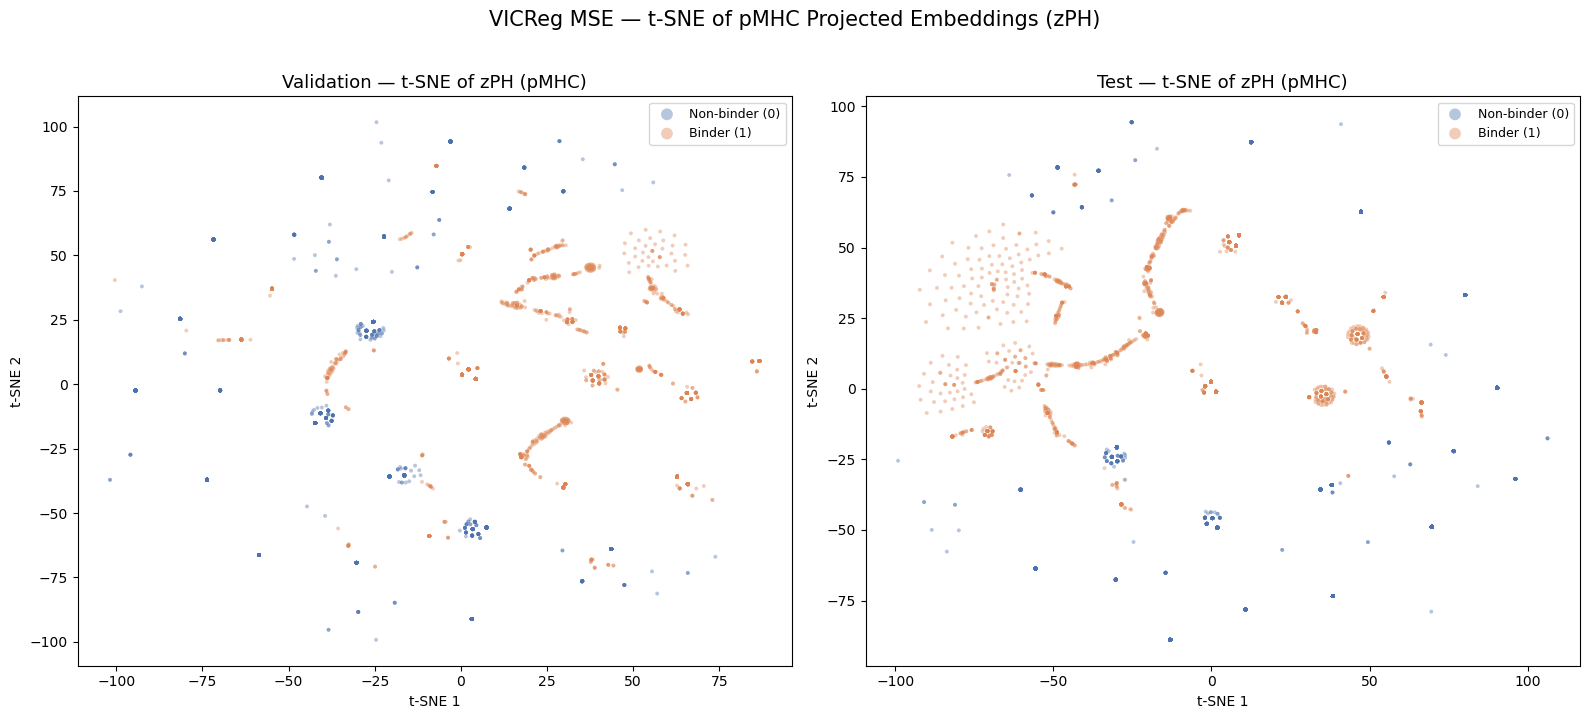

In [8]:
# ── t-SNE of TCR embeddings (zT) and pMHC embeddings (zPH) separately ──

def run_tsne_single(embs, labels, split_name, emb_label, ax,
                    perplexity=30, random_state=42):
    """
    Run t-SNE on a single embedding matrix and scatter-plot by binding label.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
    )
    coords = tsne.fit_transform(embs)

    neg_mask = labels == 0
    pos_mask = labels == 1

    ax.scatter(
        coords[neg_mask, 0], coords[neg_mask, 1],
        c="#4C72B0", label="Non-binder (0)", alpha=0.4, s=8, edgecolors="none",
    )
    ax.scatter(
        coords[pos_mask, 0], coords[pos_mask, 1],
        c="#DD8452", label="Binder (1)", alpha=0.4, s=8, edgecolors="none",
    )

    ax.set_title(f"{split_name} — t-SNE of {emb_label}", fontsize=13)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc="best", fontsize=9, markerscale=3)


# ---- TCR embeddings (zT) ----
fig_tcr, axes_tcr = plt.subplots(1, 2, figsize=(16, 7))

print("Running t-SNE on validation TCR embeddings (zT)...")
run_tsne_single(val_embs["zT"], val_embs["labels"], "Validation", "zT (TCR)", axes_tcr[0])

print("Running t-SNE on test TCR embeddings (zT)...")
run_tsne_single(test_embs["zT"], test_embs["labels"], "Test", "zT (TCR)", axes_tcr[1])

fig_tcr.suptitle("VICReg MSE — t-SNE of TCR Projected Embeddings (zT)", fontsize=15, y=1.02)
fig_tcr.tight_layout()

save_path_tcr = figure_dir / "tsne_vicreg_mse_zT_val_test.png"
fig_tcr.savefig(save_path_tcr, dpi=200, bbox_inches="tight")
print(f"Figure saved to {save_path_tcr}")
plt.show()

# ---- pMHC embeddings (zPH) ----
fig_pmhc, axes_pmhc = plt.subplots(1, 2, figsize=(16, 7))

print("Running t-SNE on validation pMHC embeddings (zPH)...")
run_tsne_single(val_embs["zPH"], val_embs["labels"], "Validation", "zPH (pMHC)", axes_pmhc[0])

print("Running t-SNE on test pMHC embeddings (zPH)...")
run_tsne_single(test_embs["zPH"], test_embs["labels"], "Test", "zPH (pMHC)", axes_pmhc[1])

fig_pmhc.suptitle("VICReg MSE — t-SNE of pMHC Projected Embeddings (zPH)", fontsize=15, y=1.02)
fig_pmhc.tight_layout()

save_path_pmhc = figure_dir / "tsne_vicreg_mse_zPH_val_test.png"
fig_pmhc.savefig(save_path_pmhc, dpi=200, bbox_inches="tight")
print(f"Figure saved to {save_path_pmhc}")
plt.show()

Compare to Randomly Generated TCRs and then Random Letters

In [17]:
# now add OLGA sequences and random sequences

checkpoint_tcr = torch.load(checkpoints_dir/'tcr_encoder_checkpoint.pth', map_location='cpu')

lora_cfg = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

tcr_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="tcr")
tcr_encoder.load_state_dict(checkpoint_tcr['tcr_model_state_dict'])
tcr_encoder.to(device).eval()

LoraModel(
  (model): ESMC(
    (embed): Embedding(64, 960)
    (transformer): TransformerStack(
      (blocks): ModuleList(
        (0-29): 30 x UnifiedTransformerBlock(
          (attn): MultiHeadAttention(
            (layernorm_qkv): Sequential(
              (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
              (1): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=2880, bias=False)
                (lora_dropout): ModuleDict(
                  (tcr): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (tcr): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (tcr): Linear(in_features=8, out_features=2880, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
 

In [18]:
# ── Load real TCR sequences from val/test CSV to estimate realistic length distribution ──

val_csv = pd.read_csv("/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv")
test_csv = pd.read_csv("/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv")

def find_first_matching_column(df, candidates, required=True):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    if required:
        raise ValueError(f"Could not find matching column from: {candidates}")
    return None

tcr_col = find_first_matching_column(
    val_csv,
    candidates=[
        "cdr3b", "cdr3b_aa", "cdr3_beta", "tcr", "tcr_sequence",
        "tcr_aa", "cdr3", "cdr3_aa", "sequence_aa"
    ],
    required=True
)

print("Detected TCR sequence column:", tcr_col)

real_tcr_all = (
    val_csv[tcr_col].dropna().astype(str).tolist() +
    test_csv[tcr_col].dropna().astype(str).tolist()
)
real_tcr_all = [s for s in real_tcr_all if len(s) > 0]

lengths = np.array([len(s) for s in real_tcr_all])
print("Length summary:", np.min(lengths), np.median(lengths), np.max(lengths))

Detected TCR sequence column: TCR_full
Length summary: 106 228.0 245


In [19]:
# ── Random amino-acid strings matched to empirical TCR length distribution ──

AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")

def generate_random_aa_sequences(n, empirical_lengths, seed=42):
    rng = np.random.default_rng(seed)
    sampled_lengths = rng.choice(empirical_lengths, size=n, replace=True)
    seqs = []
    for L in sampled_lengths:
        seq = "".join(rng.choice(AA_ALPHABET, size=int(L), replace=True))
        seqs.append(seq)
    return seqs

random_tcrs = generate_random_aa_sequences(
    n=1000,
    empirical_lengths=lengths,
    seed=42
)

print("Example random sequences:", random_tcrs[:5])

Example random sequences: ['TRNVDWVMRMGSFHMTILADCCVTTCCGNHLERHCRWAKTRVKIREFPQDMIMYCYKSKHSQDRSIWPHAQFSMLEREKTWYYNFTTYQDMKTIHCTSAKLLWEHEFWWAPFEGELYNRLACGFTTVPNPKQSSPCRIRMVHWTHLMSQVIMKWHNDVIHNLTMMDAIYWPPIEAHHEGAPWQKKHDNNAKGERMPRYTPVLYSQWMRGYPSLVCDMRTKPNYQKYDYEGT', 'RYRPHADGAMSYLVYVLHYFKCSPCFNMTGWKTFACIYAIDWQSRQSAVRRITIAWFDPFVKAYMGQMASKQVPQGFKVMHSVWGRNKIDGMVVEQCQHKRKTMYPGSKMDDNEYVRRNCILWFLHDDICCIFNAHLYPVHKKVYYSMMYGHVIFNHVWHMYRFNPQAGVFGHEEHVAGCNGSNSPKVLWYNQGTQWGSLEENHDKQHYSMWKDAWYRDGACF', 'NCYLGMSHACVDPISCVQKFYHLIFKEAGDKVEADMGLAHKKNSLTMGFHNFWLVQHFRHFWLALLVREEPAHDAWCAWETAEDRPLFCNFNQTLAGVMPLEVSYVGGFWNLYPWYCIRTDHMSDPGFMKPHTCVARHIAREQRTRHRTHDVDNFDSDQQCESMDYGAWANYNNIDNVCVKMEPEGRCKNDGHQYTEACNEFTVTGPPENMISQMRSNGSRYDKW', 'MWAASIMKKWCSVQIEQLDIYGEQEWVYWFFHLVRPVPIKMCRQRMSWNKDSWQVVSMCAFKRLAFYYITRWVPIPHHPNNIKAPNWMLCEHIIISDHEHQAHAYRFECLSNVHGLFYELMCLLGDAALCYFQQLVDFGDGHSHVSWDYPYIYNCKDWHFNKCTTRPKMMECGLEDVINMRRGTITKDSASAFPWKDFVRDIGETPEQKCKEFVRDVNVRHMMRFHFG', 'EAWCVASHMGLLMIMTKIDIDEYCLTYDEINYFEGVAIDEWAHWPCLYK

In [21]:
# ── OLGA generation ──
# Requires: pip install olga
# Then the CLI `olga-generate_sequences` should be available.
import olga

def parse_olga_output_table(path):
    try:
        df = pd.read_csv(path, sep="\t", engine="python")
    except Exception:
        df = pd.read_csv(path, sep=r"\s+", engine="python", header=None)

    aa_regex = re.compile(r"^[ACDEFGHIKLMNPQRSTVWY]+$")
    candidates = []

    for col in df.columns:
        vals = df[col].dropna().astype(str)
        if len(vals) == 0:
            continue
        frac_aa = np.mean([bool(aa_regex.match(v)) for v in vals.head(min(200, len(vals)))])
        if frac_aa > 0.6:
            candidates.append(col)

    if not candidates:
        seqs = []
        with open(path, "r") as f:
            for line in f:
                toks = re.split(r"[\t,\s]+", line.strip())
                for tok in toks:
                    if aa_regex.match(tok) and 8 <= len(tok) <= 30:
                        seqs.append(tok)
        seqs = list(dict.fromkeys(seqs))
        if not seqs:
            raise ValueError("Could not parse any amino-acid sequences from OLGA output.")
        return seqs

    best_col = None
    best_score = -1
    for col in candidates:
        vals = df[col].dropna().astype(str).tolist()
        score = 0
        for v in vals[: min(300, len(vals))]:
            if v.startswith("C"):
                score += 1
            if v.endswith("F") or v.endswith("W"):
                score += 1
            if 8 <= len(v) <= 30:
                score += 1
        if score > best_score:
            best_score = score
            best_col = col

    seqs = df[best_col].dropna().astype(str).tolist()
    seqs = [s for s in seqs if aa_regex.match(s) and 8 <= len(s) <= 30]
    seqs = list(dict.fromkeys(seqs))

    if not seqs:
        raise ValueError("Parsed OLGA column but recovered zero valid amino-acid sequences.")

    return seqs


def generate_olga_human_trb(n=1000, out_dir="/tmp/olga_gen"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"olga_humanTRB_{n}.tsv"

    olga_bin = shutil.which("olga-generate_sequences")
    if olga_bin is None:
        raise RuntimeError(
            "Could not find `olga-generate_sequences`. Install OLGA first with `pip install olga`."
        )

    cmd = [
        olga_bin,
        "--humanTRB",
        "-n", str(int(n)),
        "-o", str(out_path),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    seqs = parse_olga_output_table(out_path)
    return seqs[:n], out_path


# Run this after installing OLGA
olga_tcrs, olga_path = generate_olga_human_trb(n=1000)
print("OLGA output:", olga_path)
print("Example OLGA sequences:", olga_tcrs[:5])
print("N OLGA sequences:", len(olga_tcrs))

Running: /home/natasha/miniconda3/envs/tcr-multimodal/bin/olga-generate_sequences --humanTRB -n 1000 -o /tmp/olga_gen/olga_humanTRB_1000.tsv
/tmp/olga_gen/olga_humanTRB_1000.tsv already exists. Overwrite (y/n)? 

Traceback (most recent call last):
  File "/home/natasha/miniconda3/envs/tcr-multimodal/bin/olga-generate_sequences", line 7, in <module>
    sys.exit(main())
  File "/home/natasha/miniconda3/envs/tcr-multimodal/lib/python3.10/site-packages/olga/generate_sequences.py", line 262, in main
    if not input(outfile_name + ' already exists. Overwrite (y/n)? ').strip().lower() in ['y', 'yes']:
KeyboardInterrupt


KeyboardInterrupt: 

In [37]:
from torch.utils.data import Dataset, DataLoader

class TCRSequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = list(sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def make_tcr_only_collate_fn(tokenizer):
    def collate_fn(batch_sequences):
        tok = tokenizer(
            batch_sequences,
            padding=True,
            return_tensors="pt",
        )
        return {
            "sequences": batch_sequences,
            "input_ids": tok["input_ids"],
            "attention_mask": tok["attention_mask"],
        }
    return collate_fn

In [33]:
# ── Reuse the tokenizer attached to the loaded TCR encoder ──
tokenizer = tcr_encoder.model.tokenizer
print(type(tokenizer))
print("Tokenizer loaded from tcr_encoder.model.tokenizer")

<class 'esm.tokenization.sequence_tokenizer.EsmSequenceTokenizer'>
Tokenizer loaded from tcr_encoder.model.tokenizer


In [38]:
@torch.inference_mode()
def embed_tcr_sequences_with_loaded_encoder(
    sequences,
    tokenizer,
    tcr_encoder,
    tcr_projection,
    device,
    batch_size=8,
):
    ds = TCRSequenceDataset(sequences)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=make_tcr_only_collate_fn(tokenizer),
    )

    all_zT = []

    tcr_encoder.eval()
    tcr_projection.eval()

    for batch in loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attn_mask = batch["attention_mask"].to(device, non_blocking=True)

        emb_T = tcr_encoder(sequence_tokens=input_ids).embeddings
        mask_T = attn_mask.to(torch.bool)

        zT = tcr_projection(emb_T, mask_T)
        all_zT.append(zT.cpu().numpy())

        del input_ids, attn_mask, emb_T, mask_T, zT
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "zT": np.concatenate(all_zT, axis=0),
    }

In [39]:
tokenizer = tcr_encoder.model.tokenizer

print("Embedding OLGA-generated TCRs...")
olga_bg = embed_tcr_sequences_with_loaded_encoder(
    sequences=olga_tcrs,
    tokenizer=tokenizer,
    tcr_encoder=tcr_encoder,
    tcr_projection=tcr_projection,
    device=device,
    batch_size=8,
)
print("OLGA zT shape:", olga_bg["zT"].shape)

print("Embedding random amino-acid strings...")
random_bg = embed_tcr_sequences_with_loaded_encoder(
    sequences=random_tcrs,
    tokenizer=tokenizer,
    tcr_encoder=tcr_encoder,
    tcr_projection=tcr_projection,
    device=device,
    batch_size=8,
)
print("Random zT shape:", random_bg["zT"].shape)

Embedding OLGA-generated TCRs...
OLGA zT shape: (999, 128)
Embedding random amino-acid strings...
Random zT shape: (1000, 128)


In [40]:
# ── TCR-only t-SNE overlay with real binders/non-binders + OLGA + random ──

def run_tsne_tcr_with_extra_repertoires(
    real_embs_dict,
    zT_olga,
    zT_random,
    split_name,
    perplexity=35,
    random_state=42,
    max_real=None,
    max_olga=1000,
    max_random=1000,
):
    zT_real = real_embs_dict["zT"]
    y_real = real_embs_dict["labels"]

    rng = np.random.default_rng(random_state)

    if max_real is not None and len(zT_real) > max_real:
        idx = rng.choice(len(zT_real), size=max_real, replace=False)
        zT_real = zT_real[idx]
        y_real = y_real[idx]

    if max_olga is not None and len(zT_olga) > max_olga:
        idx = rng.choice(len(zT_olga), size=max_olga, replace=False)
        zT_olga_plot = zT_olga[idx]
    else:
        zT_olga_plot = zT_olga

    if max_random is not None and len(zT_random) > max_random:
        idx = rng.choice(len(zT_random), size=max_random, replace=False)
        zT_random_plot = zT_random[idx]
    else:
        zT_random_plot = zT_random

    X = np.vstack([zT_real, zT_olga_plot, zT_random_plot])
    groups = np.concatenate([
        np.where(y_real == 1, "Binder (real)", "Non-binder (real)"),
        np.array(["OLGA background"] * len(zT_olga_plot)),
        np.array(["Random AA strings"] * len(zT_random_plot)),
    ])

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(X) - 1)),
        random_state=random_state,
        init="pca",
        learning_rate="auto",
    )
    coords = tsne.fit_transform(X)

    plt.figure(figsize=(10, 8))

    plot_specs = {
        "Non-binder (real)": dict(alpha=0.35, s=10, label="Non-binder (real)"),
        "Binder (real)": dict(alpha=0.35, s=10, label="Binder (real)"),
        "OLGA background": dict(alpha=0.80, s=22, marker="^", label="OLGA background"),
        "Random AA strings": dict(alpha=0.80, s=22, marker="x", label="Random AA strings"),
    }

    for name, kwargs in plot_specs.items():
        mask = groups == name
        plt.scatter(coords[mask, 0], coords[mask, 1], **kwargs)

    plt.title(f"{split_name}: t-SNE of TCR projected embeddings with added backgrounds")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return coords, groups

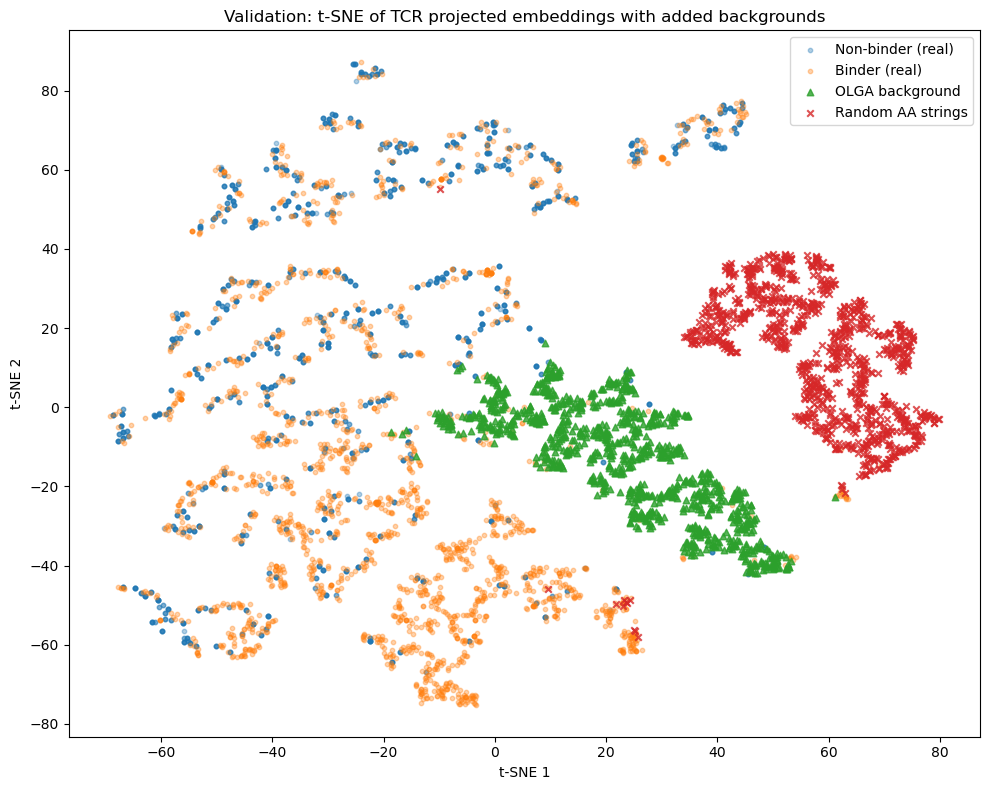

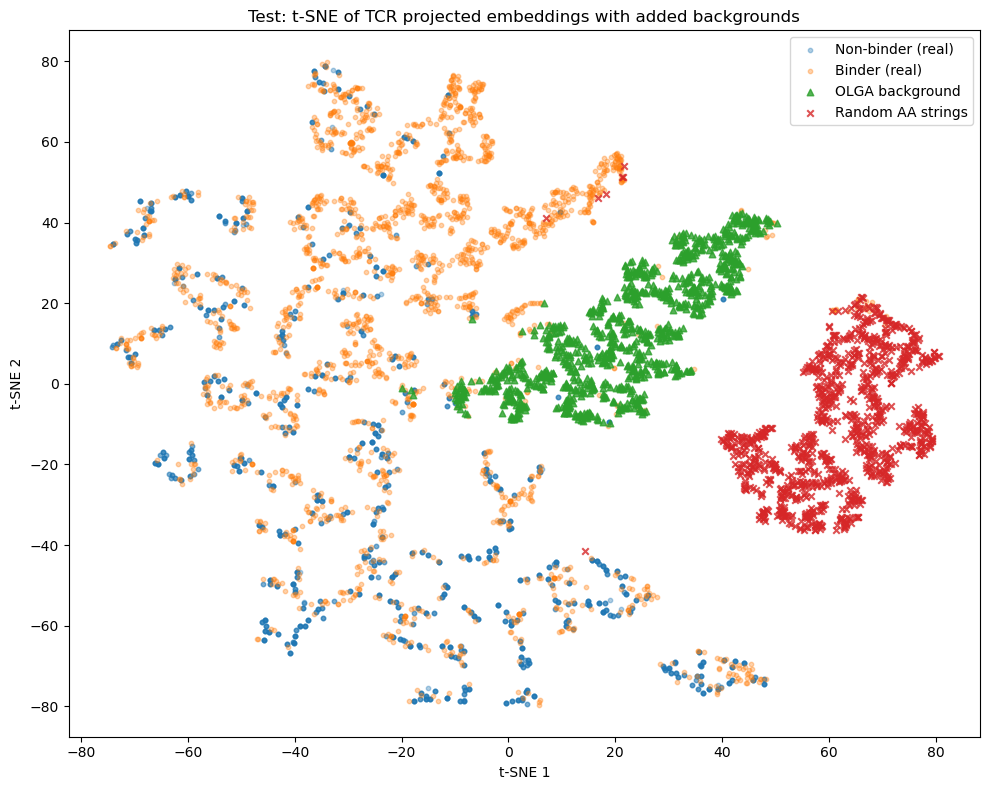

In [41]:
coords_val_bg, groups_val_bg = run_tsne_tcr_with_extra_repertoires(
    real_embs_dict=val_embs,
    zT_olga=olga_bg["zT"],
    zT_random=random_bg["zT"],
    split_name="Validation",
    perplexity=35,
    random_state=42,
)

coords_test_bg, groups_test_bg = run_tsne_tcr_with_extra_repertoires(
    real_embs_dict=test_embs,
    zT_olga=olga_bg["zT"],
    zT_random=random_bg["zT"],
    split_name="Test",
    perplexity=35,
    random_state=42,
)

In [42]:
# ── Quantitative distance-to-manifold analysis in original zT space ──

def nearest_real_tcr_distance_summary(real_zT, bg_zT, name, n_neighbors=1):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
    nn.fit(real_zT)
    dists, _ = nn.kneighbors(bg_zT)
    d = dists[:, 0]

    summary = {
        "name": name,
        "n": len(d),
        "mean": float(np.mean(d)),
        "median": float(np.median(d)),
        "p05": float(np.quantile(d, 0.05)),
        "p25": float(np.quantile(d, 0.25)),
        "p75": float(np.quantile(d, 0.75)),
        "p95": float(np.quantile(d, 0.95)),
    }
    return d, summary


def plot_nn_distance_hist(real_zT, zT_olga, zT_random, split_name):
    d_olga, s_olga = nearest_real_tcr_distance_summary(real_zT, zT_olga, "OLGA")
    d_rand, s_rand = nearest_real_tcr_distance_summary(real_zT, zT_random, "Random")

    plt.figure(figsize=(7, 4.5))
    plt.hist(d_olga, bins=50, alpha=0.6, label="OLGA → nearest real TCR", density=True)
    plt.hist(d_rand, bins=50, alpha=0.6, label="Random → nearest real TCR", density=True)
    plt.xlabel("Cosine distance to nearest real TCR in zT space")
    plt.ylabel("Density")
    plt.title(f"{split_name}: distance of added backgrounds to real TCR manifold")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(split_name, s_olga)
    print(split_name, s_rand)

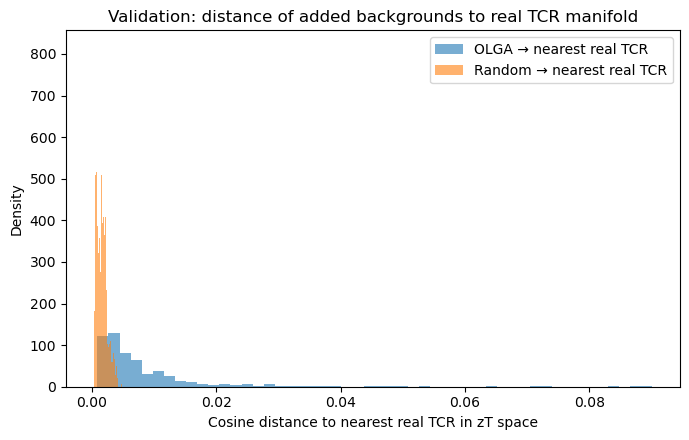

Validation {'name': 'OLGA', 'n': 999, 'mean': 0.007726438343524933, 'median': 0.005003631114959717, 'p05': 0.001504832529462874, 'p25': 0.0028620660305023193, 'p75': 0.009296417236328125, 'p95': 0.022807089611887932}
Validation {'name': 'Random', 'n': 1000, 'mean': 0.0015254599275067449, 'median': 0.001475214958190918, 'p05': 0.00047975481720641255, 'p25': 0.0007692724466323853, 'p75': 0.0020346343517303467, 'p95': 0.0032385378144681454}


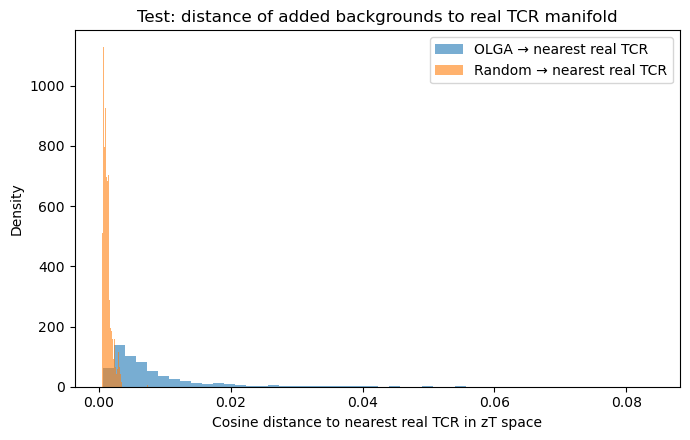

Test {'name': 'OLGA', 'n': 999, 'mean': 0.008405765518546104, 'median': 0.0056296586990356445, 'p05': 0.0018384158611297607, 'p25': 0.0033887922763824463, 'p75': 0.009433329105377197, 'p95': 0.026224948465824127}
Test {'name': 'Random', 'n': 1000, 'mean': 0.0012603836366906762, 'median': 0.0011204779148101807, 'p05': 0.0006200820207595825, 'p25': 0.0007980912923812866, 'p75': 0.0014550238847732544, 'p95': 0.0025373930111527443}


In [43]:
plot_nn_distance_hist(val_embs["zT"], olga_bg["zT"], random_bg["zT"], "Validation")
plot_nn_distance_hist(test_embs["zT"], olga_bg["zT"], random_bg["zT"], "Test")

Cross-Reactivity Analysis

In [8]:
# ── Collect latent embeddings + pair_id from a loader ──

@torch.no_grad()
def collect_embeddings_with_pair_id(loader, tcr_projection, pmhc_projection, device):
    """
    Run all batches through the projection heads and collect:
      - zT (TCR embedding)
      - zPH (pMHC embedding)
      - binding labels
      - pair_id
    """
    tcr_projection.eval()
    pmhc_projection.eval()

    all_zT = []
    all_zPH = []
    all_labels = []
    all_pair_ids = []

    for batch in loader:
        emb_T  = batch["emb_T"].to(device)
        mask_T = batch["mask_T"].to(device)
        emb_P  = batch["emb_P"].to(device)
        mask_P = batch["mask_P"].to(device)
        emb_H  = batch["emb_H"].to(device)
        mask_H = batch["mask_H"].to(device)

        zT  = tcr_projection(emb_T, mask_T)
        zPH = pmhc_projection(emb_P, mask_P, emb_H, mask_H)

        all_zT.append(zT.cpu().numpy())
        all_zPH.append(zPH.cpu().numpy())

        labels = batch["binding_flag"]
        if torch.is_tensor(labels):
            labels = labels.cpu().numpy()
        else:
            labels = np.array(labels)
        all_labels.append(labels)

        # pair_id handling
        pair_ids = batch["pair_id"]
        if torch.is_tensor(pair_ids):
            pair_ids = pair_ids.cpu().numpy()
        else:
            pair_ids = np.array(pair_ids)

        # force to 1D string array for safe merging later
        pair_ids = pair_ids.reshape(-1).astype(str)
        all_pair_ids.append(pair_ids)

    return {
        "zT": np.concatenate(all_zT, axis=0),
        "zPH": np.concatenate(all_zPH, axis=0),
        "labels": np.concatenate(all_labels, axis=0).astype(int),
        "pair_id": np.concatenate(all_pair_ids, axis=0).astype(str),
    }


print("Collecting validation embeddings with pair_id...")
val_embs = collect_embeddings_with_pair_id(val_loader, tcr_projection, pmhc_projection, device)
print(f"Val: {val_embs['zT'].shape[0]} samples")

print("Collecting test embeddings with pair_id...")
test_embs = collect_embeddings_with_pair_id(test_loader, tcr_projection, pmhc_projection, device)
print(f"Test: {test_embs['zT'].shape[0]} samples")

Val: 3944 samples
Test: 4182 samples


In [9]:
import pandas as pd
from pathlib import Path

val_csv_path = Path("/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv")
test_csv_path = Path("/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv")

val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print("VAL columns:")
print(val_df.columns.tolist())
print("\nTEST columns:")
print(test_df.columns.tolist())

print("\nVAL head:")
display(val_df.head(3))

print("\nTEST head:")
display(test_df.head(3))

VAL columns:
['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'pair_id_negative', 'TCRa', 'TCRb']

TEST columns:
['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'pair_id_negative', 'TCRa', 'TCRb']

VAL head:


,pair_id,Peptide,HLA_sequence,TCR_full,binding_flag,pair_id_negative,TCRa,TCRb
0,pair_000,ASFRPELAEFW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLL...,1,NaN,NaN,NaN
1,pair_001,ASFSPELRMAW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLL...,1,NaN,NaN,NaN
2,pair_002,GSLAPEIRMYW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLL...,1,NaN,NaN,NaN



TEST head:


,pair_id,Peptide,HLA_sequence,TCR_full,binding_flag,pair_id_negative,TCRa,TCRb
0,pair_000,TSTLQEQIGW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GNSVTQMEGPVTLSEEAFLTINCTYTATGYPSLFWYVQYPGEGLQL...,1,NaN,NaN,NaN
1,pair_001,GSLSPELRPIF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLL...,1,NaN,NaN,NaN
2,pair_002,GTIRPEIPDYF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,GEDVEQSLFLSVREGDSSVINCTYTDSSSTYLYWYKQEPGAGLQLL...,1,NaN,NaN,NaN


In [10]:
# ── Helpers to identify metadata columns and merge onto embeddings ──

def find_first_matching_column(df, candidates, required=True):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    # partial matching fallback
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c

    if required:
        raise ValueError(f"Could not find any matching column from candidates: {candidates}")
    return None


def attach_metadata_from_csv(embs, df, split_name="split"):
    df = df.copy()

    pair_col = find_first_matching_column(
        df,
        candidates=["pair_id", "pairid", "id_pair", "pair identifier"]
    )

    pep_col = find_first_matching_column(
        df,
        candidates=["peptide", "peptide_seq", "peptide_sequence", "antigen_peptide", "epitope"]
    )

    hla_col = find_first_matching_column(
        df,
        candidates=["mhc", "hla", "mhc_allele", "hla_allele", "mhc_restriction"],
        required=False
    )

    bind_col = find_first_matching_column(
        df,
        candidates=["binding_flag", "binder", "label", "target", "y"],
        required=False
    )

    meta_cols = [pair_col, pep_col]
    if hla_col is not None:
        meta_cols.append(hla_col)
    if bind_col is not None:
        meta_cols.append(bind_col)

    meta = df[meta_cols].copy()
    meta[pair_col] = meta[pair_col].astype(str)

    emb_df = pd.DataFrame({
        "pair_id": embs["pair_id"].astype(str),
        "label_from_emb": embs["labels"].astype(int),
    })

    merged = emb_df.merge(
        meta,
        left_on="pair_id",
        right_on=pair_col,
        how="left",
        validate="one_to_one"
    )

    missing = merged[pep_col].isna().sum()
    print(f"{split_name}: merged {len(merged)} rows; missing peptide metadata for {missing} rows")

    if bind_col is not None:
        agreement = (merged["label_from_emb"].astype(int) == merged[bind_col].astype(int)).mean()
        print(f"{split_name}: label agreement between embeddings and CSV = {agreement:.4f}")

    # define peptide grouping key
    merged["peptide_id"] = merged[pep_col].astype(str)

    # define stricter pMHC grouping if HLA exists
    if hla_col is not None:
        merged["pmhc_id"] = merged[pep_col].astype(str) + " | " + merged[hla_col].astype(str)
    else:
        merged["pmhc_id"] = merged["peptide_id"]

    # attach metadata names for convenience
    merged.attrs["pair_col"] = pair_col
    merged.attrs["pep_col"] = pep_col
    merged.attrs["hla_col"] = hla_col
    merged.attrs["bind_col"] = bind_col

    return merged

In [11]:
val_meta = attach_metadata_from_csv(val_embs, val_df, split_name="Validation")
test_meta = attach_metadata_from_csv(test_embs, test_df, split_name="Test")

display(val_meta.head())
display(test_meta.head())

print("Validation peptide examples:", val_meta["peptide_id"].dropna().unique()[:10])
print("Test peptide examples:", test_meta["peptide_id"].dropna().unique()[:10])

Validation: merged 3944 rows; missing peptide metadata for 0 rows
Validation: label agreement between embeddings and CSV = 1.0000
Test: merged 4182 rows; missing peptide metadata for 0 rows
Test: label agreement between embeddings and CSV = 1.0000


,pair_id,label_from_emb,Peptide,HLA_sequence,binding_flag,peptide_id,pmhc_id
0,pair_000,1,ASFRPELAEFW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,ASFRPELAEFW,ASFRPELAEFW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
1,pair_001,1,ASFSPELRMAW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,ASFSPELRMAW,ASFSPELRMAW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
2,pair_002,1,GSLAPEIRMYW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,GSLAPEIRMYW,GSLAPEIRMYW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
3,pair_003,1,GTIRPEIPDYF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,GTIRPEIPDYF,GTIRPEIPDYF | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
4,pair_004,1,GTIRPEIREMW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,GTIRPEIREMW,GTIRPEIREMW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...


,pair_id,label_from_emb,Peptide,HLA_sequence,binding_flag,peptide_id,pmhc_id
0,pair_000,1,TSTLQEQIGW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,TSTLQEQIGW,TSTLQEQIGW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFY...
1,pair_001,1,GSLSPELRPIF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,GSLSPELRPIF,GSLSPELRPIF | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
2,pair_002,1,GTIRPEIPDYF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,GTIRPEIPDYF,GTIRPEIPDYF | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
3,pair_003,1,KAFSPEVIPMF,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,KAFSPEVIPMF,KAFSPEVIPMF | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...
4,pair_004,1,KSLTPEVRGYW,MRVTAPRTVLLLLWGAVALTETWAGSHSMRYFYTAMSRPGRGEPRF...,1,KSLTPEVRGYW,KSLTPEVRGYW | MRVTAPRTVLLLLWGAVALTETWAGSHSMRYF...


Validation peptide examples: ['ASFRPELAEFW' 'ASFSPELRMAW' 'GSLAPEIRMYW' 'GTIRPEIPDYF' 'GTIRPEIREMW'
 'KAFSPEVIPMF' 'KSCTPEVREYF' 'KSFVPELKPAF' 'KSLAPEVRDLF' 'KSLTPEVRGYW']
Test peptide examples: ['TSTLQEQIGW' 'GSLSPELRPIF' 'GTIRPEIPDYF' 'KAFSPEVIPMF' 'KSLTPEVRGYW'
 'LTISPEIPPYF' 'RSLAPEVRGYW' 'VSFGLQFQF' 'KSKRTPMGF' 'ELAGIGILTV']


In [12]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

def cosine_pair_score(zT, zPH):
    return np.sum(zT * zPH, axis=1) / (
        np.linalg.norm(zT, axis=1) * np.linalg.norm(zPH, axis=1) + 1e-8
    )

val_scores = cosine_pair_score(val_embs["zT"], val_embs["zPH"])
test_scores = cosine_pair_score(test_embs["zT"], test_embs["zPH"])

val_meta["score"] = val_scores
test_meta["score"] = test_scores

print("Val AUROC:", roc_auc_score(val_meta["label_from_emb"], val_meta["score"]))
print("Test AUROC:", roc_auc_score(test_meta["label_from_emb"], test_meta["score"]))

Val AUROC: 0.6135635288065844
Test AUROC: 0.4791272914757103


In [13]:
from scipy.spatial.distance import pdist
from scipy.stats import mannwhitneyu

def many_to_one_distance_analysis(embs, meta_df, group_col="peptide_id", min_group_size=3, random_n=5000, seed=42):
    rng = np.random.default_rng(seed)

    labels = meta_df["label_from_emb"].values.astype(int)
    group_ids = meta_df[group_col].astype(str).values
    zT = embs["zT"]

    pos_mask = labels == 1
    zT_pos = zT[pos_mask]
    groups_pos = group_ids[pos_mask]

    # collect within-group distances
    within_dists = []
    group_sizes = {}

    unique_groups = pd.Series(groups_pos).value_counts()
    valid_groups = unique_groups[unique_groups >= min_group_size].index.tolist()

    for g in valid_groups:
        idx = np.where(groups_pos == g)[0]
        vecs = zT_pos[idx]
        d = pdist(vecs, metric="cosine")
        within_dists.extend(d.tolist())
        group_sizes[g] = len(idx)

    within_dists = np.array(within_dists)

    # random baseline from positive TCRs
    if len(zT_pos) > 1:
        sample_size = min(len(zT_pos), random_n)
        rand_idx = rng.choice(len(zT_pos), size=sample_size, replace=False)
        random_vecs = zT_pos[rand_idx]
        random_dists = pdist(random_vecs, metric="cosine")
    else:
        random_dists = np.array([])

    stats = {
        "n_positive_pairs": int(pos_mask.sum()),
        "n_valid_groups": len(valid_groups),
        "median_group_size": np.median(list(group_sizes.values())) if group_sizes else np.nan,
        "within_mean": float(np.mean(within_dists)) if len(within_dists) else np.nan,
        "within_median": float(np.median(within_dists)) if len(within_dists) else np.nan,
        "random_mean": float(np.mean(random_dists)) if len(random_dists) else np.nan,
        "random_median": float(np.median(random_dists)) if len(random_dists) else np.nan,
    }

    if len(within_dists) and len(random_dists):
        u_stat, p_val = mannwhitneyu(within_dists, random_dists, alternative="less")
        stats["mannwhitney_u"] = float(u_stat)
        stats["p_value_less"] = float(p_val)
    else:
        stats["mannwhitney_u"] = np.nan
        stats["p_value_less"] = np.nan

    return within_dists, random_dists, stats

In [14]:
def plot_many_to_one(within_dists, random_dists, stats, split_name, group_label):
    plt.figure(figsize=(7, 4.5))
    plt.hist(random_dists, bins=60, alpha=0.55, label="Random positive TCR pairs", density=True)
    plt.hist(within_dists, bins=60, alpha=0.55, label=f"Same {group_label} positive TCR pairs", density=True)
    plt.xlabel("Cosine distance in TCR latent space")
    plt.ylabel("Density")
    plt.title(f"{split_name}: many-to-one consistency")
    plt.legend()
    plt.show()

    print(f"{split_name} | grouping: {group_label}")
    for k, v in stats.items():
        print(f"{k}: {v}")

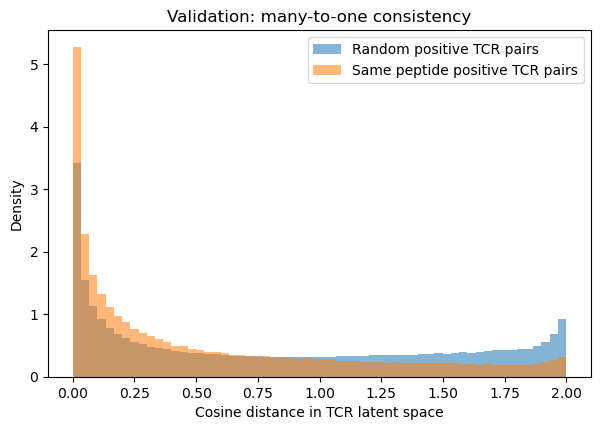

Validation | grouping: peptide
n_positive_pairs: 1944
n_valid_groups: 60
median_group_size: 5.5
within_mean: 0.546994374353712
within_median: 0.3035121342072718
random_mean: 0.8293881409054991
random_median: 0.7135750705146438
mannwhitney_u: 167407845223.0
p_value_less: 0.0


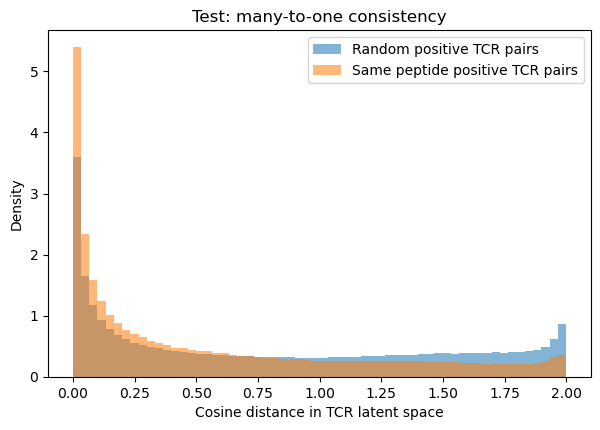

Test | grouping: peptide
n_positive_pairs: 2182
n_valid_groups: 65
median_group_size: 6.0
within_mean: 0.5731814065844376
within_median: 0.3239329720722998
random_mean: 0.8049744464842182
random_median: 0.672233980449116
mannwhitney_u: 259579535402.5
p_value_less: 0.0


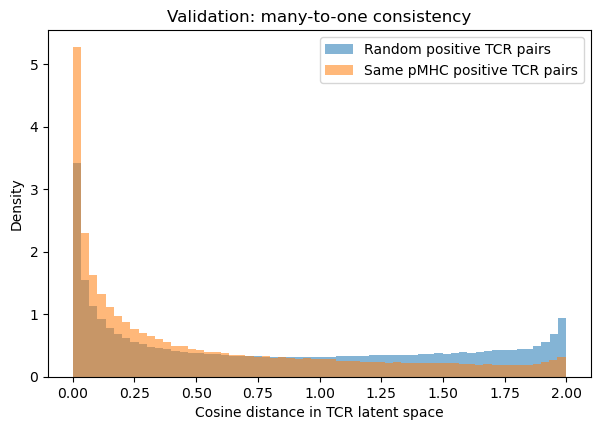

Validation | grouping: pMHC
n_positive_pairs: 1944
n_valid_groups: 56
median_group_size: 6.5
within_mean: 0.5470690165060842
within_median: 0.30361373047037005
random_mean: 0.8293881409054991
random_median: 0.7135750705146438
mannwhitney_u: 167369994228.5
p_value_less: 0.0


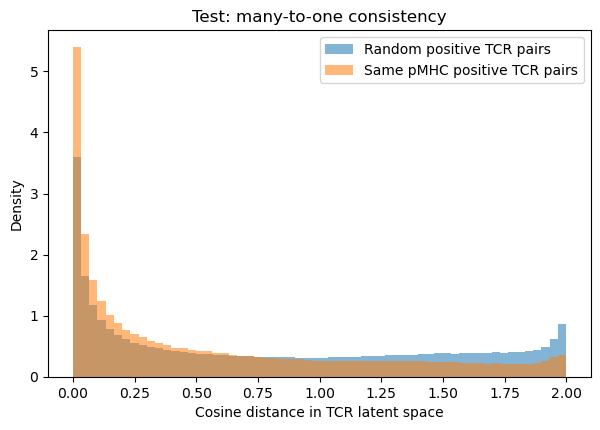

Test | grouping: pMHC
n_positive_pairs: 2182
n_valid_groups: 62
median_group_size: 7.0
within_mean: 0.5732191522744018
within_median: 0.32399629444107414
random_mean: 0.8049744464842182
random_median: 0.672233980449116
mannwhitney_u: 259559233162.5
p_value_less: 0.0


In [15]:
# Peptide-level grouping
val_within_pep, val_random_pep, val_stats_pep = many_to_one_distance_analysis(
    val_embs, val_meta, group_col="peptide_id", min_group_size=3
)
test_within_pep, test_random_pep, test_stats_pep = many_to_one_distance_analysis(
    test_embs, test_meta, group_col="peptide_id", min_group_size=3
)

plot_many_to_one(val_within_pep, val_random_pep, val_stats_pep, "Validation", "peptide")
plot_many_to_one(test_within_pep, test_random_pep, test_stats_pep, "Test", "peptide")

# pMHC-level grouping
val_within_pmhc, val_random_pmhc, val_stats_pmhc = many_to_one_distance_analysis(
    val_embs, val_meta, group_col="pmhc_id", min_group_size=3
)
test_within_pmhc, test_random_pmhc, test_stats_pmhc = many_to_one_distance_analysis(
    test_embs, test_meta, group_col="pmhc_id", min_group_size=3
)

plot_many_to_one(val_within_pmhc, val_random_pmhc, val_stats_pmhc, "Validation", "pMHC")
plot_many_to_one(test_within_pmhc, test_random_pmhc, test_stats_pmhc, "Test", "pMHC")

/tmp/ipykernel_1151740/4193202890.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


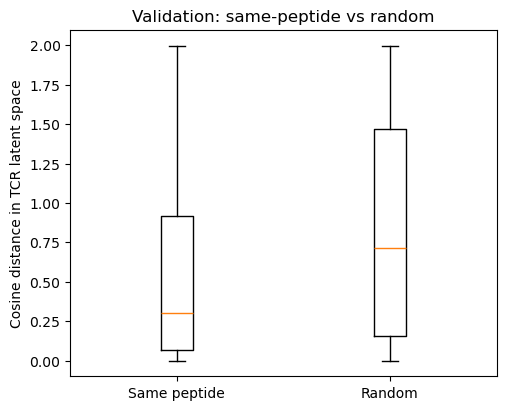

/tmp/ipykernel_1151740/4193202890.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


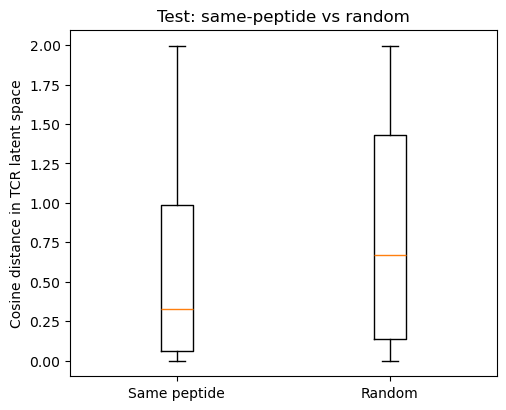

In [16]:
def plot_many_to_one_box(within_dists, random_dists, split_name, group_label):
    plt.figure(figsize=(5.5, 4.5))
    plt.boxplot(
        [within_dists, random_dists],
        labels=[f"Same {group_label}", "Random"],
        showfliers=False
    )
    plt.ylabel("Cosine distance in TCR latent space")
    plt.title(f"{split_name}: same-{group_label} vs random")
    plt.show()

plot_many_to_one_box(val_within_pep, val_random_pep, "Validation", "peptide")
plot_many_to_one_box(test_within_pep, test_random_pep, "Test", "peptide")

In [17]:
def summarise_group_sizes(meta_df, group_col="peptide_id"):
    pos = meta_df[meta_df["label_from_emb"] == 1].copy()
    summary = (
        pos.groupby(group_col)
           .size()
           .reset_index(name="n_positive_tcrs")
           .sort_values("n_positive_tcrs", ascending=False)
    )
    return summary

val_pep_summary = summarise_group_sizes(val_meta, "peptide_id")
test_pep_summary = summarise_group_sizes(test_meta, "peptide_id")

display(val_pep_summary.head(20))
display(test_pep_summary.head(20))

,peptide_id,n_positive_tcrs
120,KLGGALQAK,636
78,GILGFVFTL,187
229,RAKFKQLL,81
23,AVFDRKSDAK,77
113,IVTDFSVIK,52
335,YLQPRTFLL,41
162,LLWNGPMAV,38
261,RVRAYTYSK,36
274,SPRWYFYYL,33
79,GLCTLVAML,32


,peptide_id,n_positive_tcrs
133,KLGGALQAK,686
76,GILGFVFTL,192
152,KSKRTPMGF,103
15,AVFDRKSDAK,89
234,RAKFKQLL,75
369,YLQPRTFLL,50
289,SPRWYFYYL,48
317,TTDPSFLGRY,37
77,GLCTLVAML,36
174,LLWNGPMAV,34


Are TCRs that bind the same peptide close to that peptide anchor in the aligned latent space?

In [18]:
import pandas as pd
import numpy as np

def get_top_groups(meta_df, group_col="pmhc_id", label_col="label_from_emb", top_k=8, min_count=5):
    pos = meta_df[meta_df[label_col] == 1].copy()
    counts = (
        pos.groupby(group_col)
        .size()
        .reset_index(name="n_pos")
        .sort_values("n_pos", ascending=False)
    )
    counts = counts[counts["n_pos"] >= min_count]
    top_groups = counts.head(top_k)[group_col].tolist()
    return counts, top_groups

In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_grouped_joint_tsne(
    embs,
    meta_df,
    split_name="Validation",
    group_col="pmhc_id",
    top_k=8,
    min_count=5,
    perplexity=30,
    random_state=42,
    annotate_anchors=True
):
    """
    Visualise selected positive TCR groups and their corresponding pMHC anchors
    in a single t-SNE projection of the aligned latent space.
    """
    pos_mask = meta_df["label_from_emb"].values.astype(int) == 1
    pos_meta = meta_df.loc[pos_mask].copy().reset_index(drop=True)
    zT_pos = embs["zT"][pos_mask]
    zPH_pos = embs["zPH"][pos_mask]

    counts, top_groups = get_top_groups(
        pos_meta,
        group_col=group_col,
        label_col="label_from_emb",
        top_k=top_k,
        min_count=min_count
    )

    sel_mask = pos_meta[group_col].isin(top_groups).values
    pos_meta_sel = pos_meta.loc[sel_mask].copy().reset_index(drop=True)
    zT_sel = zT_pos[sel_mask]
    zPH_sel = zPH_pos[sel_mask]

    # Build one anchor per group as mean zPH
    anchor_rows = []
    anchor_vecs = []
    for g in top_groups:
        idx = np.where(pos_meta_sel[group_col].values == g)[0]
        if len(idx) == 0:
            continue
        anchor_rows.append(g)
        anchor_vecs.append(zPH_sel[idx].mean(axis=0))

    anchor_vecs = np.stack(anchor_vecs, axis=0)

    # Stack TCR points + anchor points into one t-SNE run
    X = np.vstack([zT_sel, anchor_vecs])
    point_type = np.array(["TCR"] * len(zT_sel) + ["anchor"] * len(anchor_vecs))
    point_group = np.concatenate([
        pos_meta_sel[group_col].astype(str).values,
        np.array(anchor_rows, dtype=str)
    ])

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(X) - 1)),
        random_state=random_state,
        init="pca",
        learning_rate="auto"
    )
    coords = tsne.fit_transform(X)

    coords_tcr = coords[:len(zT_sel)]
    coords_anchor = coords[len(zT_sel):]

    # map each group to a colour
    unique_groups = list(anchor_rows)
    cmap = plt.cm.get_cmap("tab10", len(unique_groups))
    colour_map = {g: cmap(i) for i, g in enumerate(unique_groups)}

    plt.figure(figsize=(10, 8))

    # plot TCRs by group
    for g in unique_groups:
        idx = np.where(pos_meta_sel[group_col].astype(str).values == str(g))[0]
        plt.scatter(
            coords_tcr[idx, 0],
            coords_tcr[idx, 1],
            s=28,
            alpha=0.7,
            color=colour_map[g],
            label=f"{g} TCRs"
        )

    # plot anchors
    for i, g in enumerate(unique_groups):
        plt.scatter(
            coords_anchor[i, 0],
            coords_anchor[i, 1],
            s=260,
            marker="X",
            color=colour_map[g],
            edgecolors="black",
            linewidths=1.2
        )
        if annotate_anchors:
            short_label = str(g)
            if len(short_label) > 20:
                short_label = short_label[:20] + "..."
            plt.text(
                coords_anchor[i, 0],
                coords_anchor[i, 1],
                short_label,
                fontsize=8,
                ha="left",
                va="bottom"
            )

    plt.title(f"{split_name}: joint t-SNE of positive TCRs and {group_col} anchors")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

    return counts

/tmp/ipykernel_1151740/2676905487.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_groups))


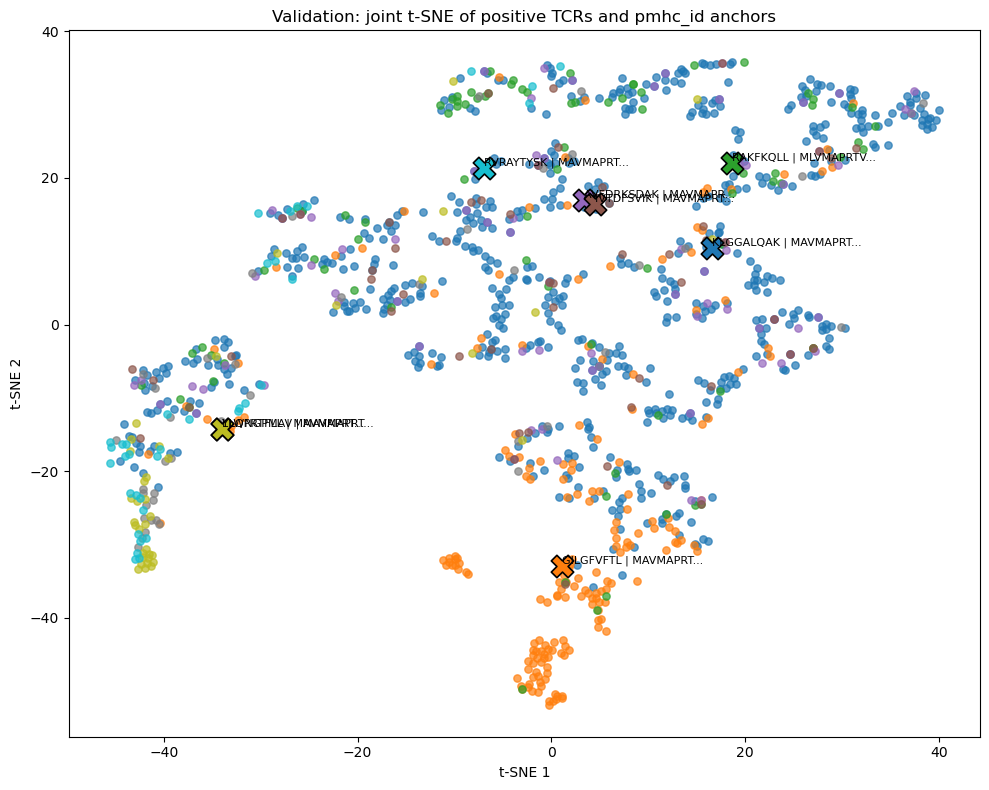

/tmp/ipykernel_1151740/2676905487.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_groups))


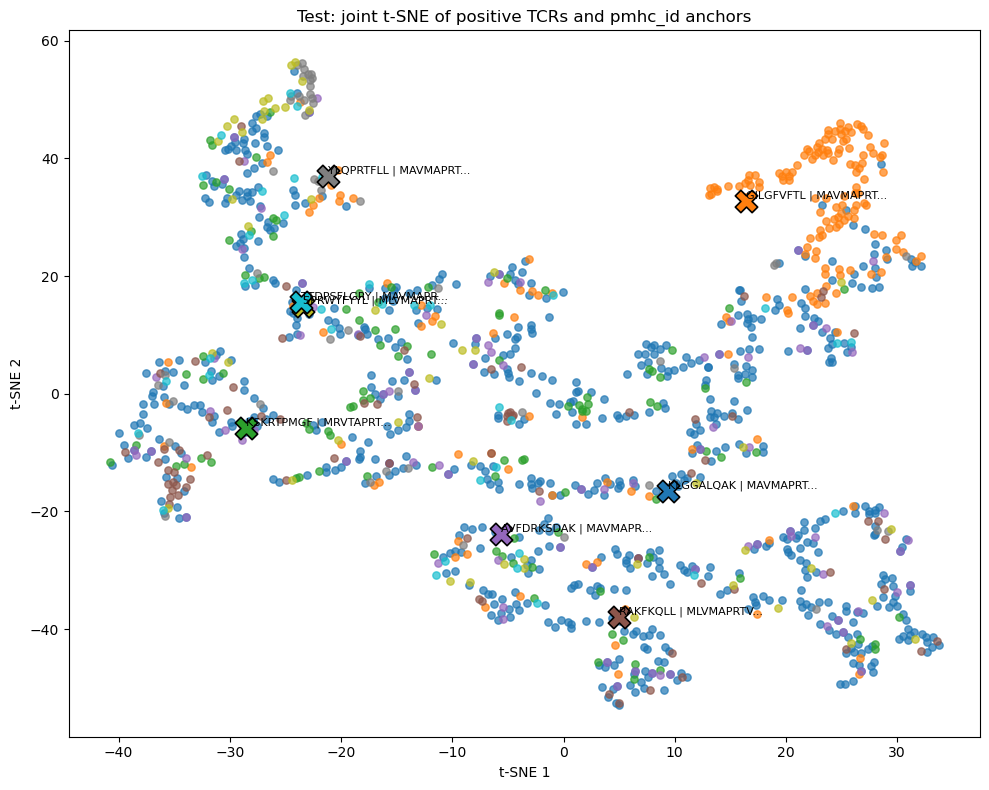

In [20]:
val_counts = plot_grouped_joint_tsne(
    val_embs,
    val_meta,
    split_name="Validation",
    group_col="pmhc_id",   # or "peptide_id"
    top_k=8,
    min_count=5,
    perplexity=25
)

test_counts = plot_grouped_joint_tsne(
    test_embs,
    test_meta,
    split_name="Test",
    group_col="pmhc_id",   # or "peptide_id"
    top_k=8,
    min_count=5,
    perplexity=25
)

In [21]:
def plot_grouped_joint_tsne_with_edges(
    embs,
    meta_df,
    split_name="Validation",
    group_col="pmhc_id",
    top_k=6,
    min_count=5,
    perplexity=25,
    random_state=42
):
    pos_mask = meta_df["label_from_emb"].values.astype(int) == 1
    pos_meta = meta_df.loc[pos_mask].copy().reset_index(drop=True)
    zT_pos = embs["zT"][pos_mask]
    zPH_pos = embs["zPH"][pos_mask]

    counts, top_groups = get_top_groups(
        pos_meta,
        group_col=group_col,
        label_col="label_from_emb",
        top_k=top_k,
        min_count=min_count
    )

    sel_mask = pos_meta[group_col].isin(top_groups).values
    pos_meta_sel = pos_meta.loc[sel_mask].copy().reset_index(drop=True)
    zT_sel = zT_pos[sel_mask]
    zPH_sel = zPH_pos[sel_mask]

    anchor_rows = []
    anchor_vecs = []
    for g in top_groups:
        idx = np.where(pos_meta_sel[group_col].values == g)[0]
        anchor_rows.append(g)
        anchor_vecs.append(zPH_sel[idx].mean(axis=0))
    anchor_vecs = np.stack(anchor_vecs, axis=0)

    X = np.vstack([zT_sel, anchor_vecs])
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(X) - 1)),
        random_state=random_state,
        init="pca",
        learning_rate="auto"
    )
    coords = tsne.fit_transform(X)

    coords_tcr = coords[:len(zT_sel)]
    coords_anchor = coords[len(zT_sel):]

    unique_groups = list(anchor_rows)
    cmap = plt.cm.get_cmap("tab10", len(unique_groups))
    colour_map = {g: cmap(i) for i, g in enumerate(unique_groups)}
    anchor_coord_map = {g: coords_anchor[i] for i, g in enumerate(unique_groups)}

    plt.figure(figsize=(10, 8))

    # draw edges first
    group_vals = pos_meta_sel[group_col].astype(str).values
    for i, g in enumerate(group_vals):
        g_match = next(x for x in unique_groups if str(x) == g)
        ax = anchor_coord_map[g_match]
        tx = coords_tcr[i]
        plt.plot(
            [tx[0], ax[0]],
            [tx[1], ax[1]],
            color=colour_map[g_match],
            alpha=0.15,
            linewidth=0.7
        )

    # draw TCRs
    for g in unique_groups:
        idx = np.where(pos_meta_sel[group_col].astype(str).values == str(g))[0]
        plt.scatter(
            coords_tcr[idx, 0],
            coords_tcr[idx, 1],
            s=26,
            alpha=0.7,
            color=colour_map[g],
            label=f"{g} TCRs"
        )

    # draw anchors
    for i, g in enumerate(unique_groups):
        plt.scatter(
            coords_anchor[i, 0],
            coords_anchor[i, 1],
            s=300,
            marker="X",
            color=colour_map[g],
            edgecolors="black",
            linewidths=1.2
        )

    plt.title(f"{split_name}: positive TCRs linked to their {group_col} anchor")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1151740/685213570.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_groups))


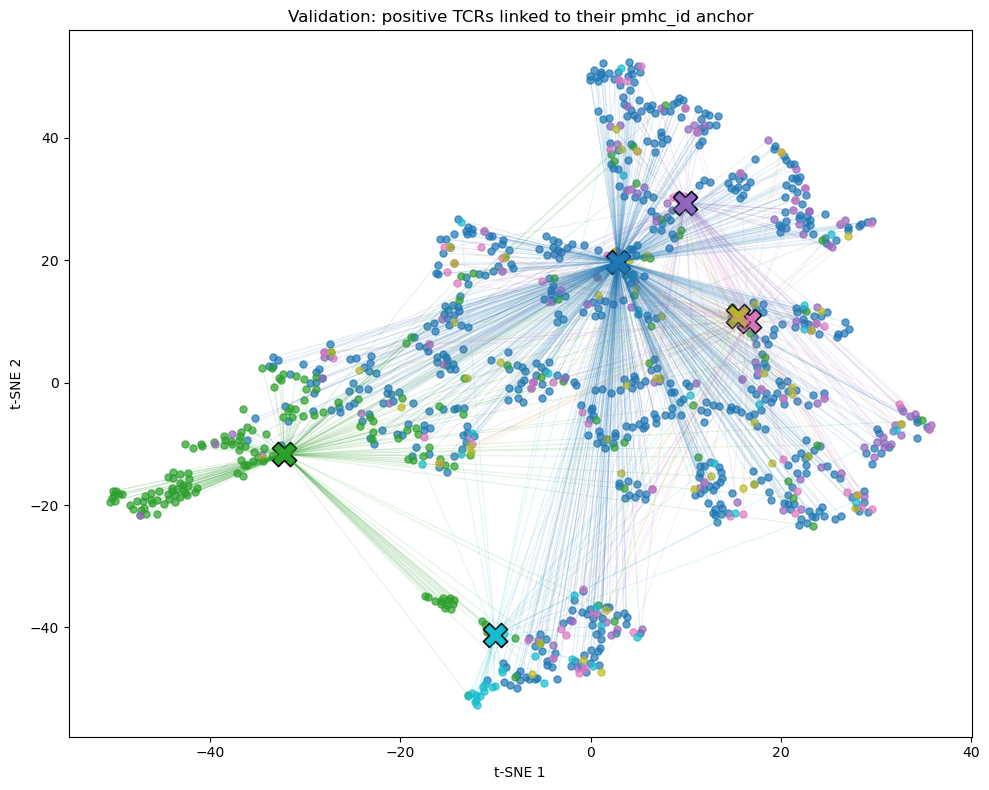

/tmp/ipykernel_1151740/685213570.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_groups))


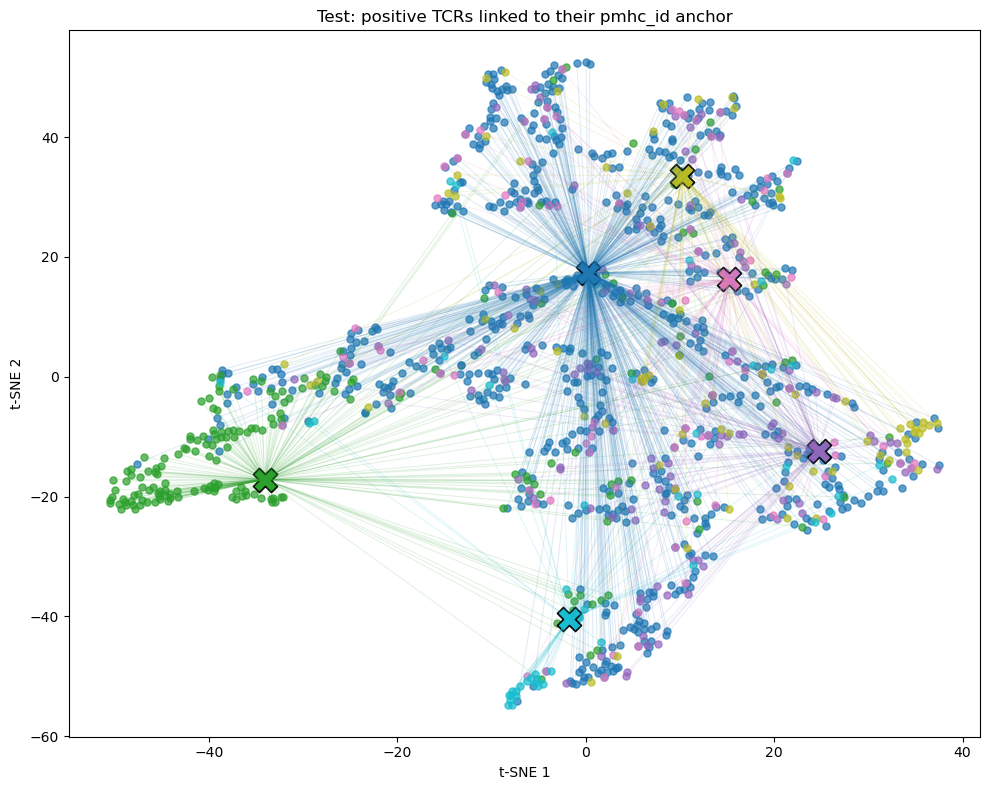

In [22]:
plot_grouped_joint_tsne_with_edges(
    val_embs,
    val_meta,
    split_name="Validation",
    group_col="pmhc_id",
    top_k=6,
    min_count=5,
    perplexity=25
)

plot_grouped_joint_tsne_with_edges(
    test_embs,
    test_meta,
    split_name="Test",
    group_col="pmhc_id",
    top_k=6,
    min_count=5,
    perplexity=25
)

In [23]:
from scipy.spatial.distance import cdist
from scipy.stats import mannwhitneyu

def own_anchor_vs_other_anchor_analysis(
    embs,
    meta_df,
    group_col="pmhc_id",
    min_count=3
):
    pos_mask = meta_df["label_from_emb"].values.astype(int) == 1
    pos_meta = meta_df.loc[pos_mask].copy().reset_index(drop=True)
    zT_pos = embs["zT"][pos_mask]
    zPH_pos = embs["zPH"][pos_mask]

    group_counts = pos_meta[group_col].value_counts()
    valid_groups = group_counts[group_counts >= min_count].index.tolist()

    keep = pos_meta[group_col].isin(valid_groups).values
    pos_meta = pos_meta.loc[keep].copy().reset_index(drop=True)
    zT_pos = zT_pos[keep]
    zPH_pos = zPH_pos[keep]

    # build one anchor per group
    unique_groups = pos_meta[group_col].astype(str).unique().tolist()
    anchor_vecs = []
    for g in unique_groups:
        idx = np.where(pos_meta[group_col].astype(str).values == g)[0]
        anchor_vecs.append(zPH_pos[idx].mean(axis=0))
    anchor_vecs = np.stack(anchor_vecs, axis=0)

    group_to_ix = {g: i for i, g in enumerate(unique_groups)}
    group_ix = np.array([group_to_ix[g] for g in pos_meta[group_col].astype(str).values])

    D = cdist(zT_pos, anchor_vecs, metric="cosine")

    own_dists = D[np.arange(len(D)), group_ix]

    other_dists = []
    nearest_wrong_dists = []

    for i in range(len(D)):
        mask = np.ones(D.shape[1], dtype=bool)
        mask[group_ix[i]] = False
        wrong = D[i, mask]
        other_dists.extend(wrong.tolist())
        nearest_wrong_dists.append(np.min(wrong))

    other_dists = np.array(other_dists)
    nearest_wrong_dists = np.array(nearest_wrong_dists)

    stats = {
        "n_points": len(own_dists),
        "n_groups": len(unique_groups),
        "own_mean": float(np.mean(own_dists)),
        "own_median": float(np.median(own_dists)),
        "nearest_wrong_mean": float(np.mean(nearest_wrong_dists)),
        "nearest_wrong_median": float(np.median(nearest_wrong_dists)),
    }

    u, p = mannwhitneyu(own_dists, nearest_wrong_dists, alternative="less")
    stats["mannwhitney_u"] = float(u)
    stats["p_value_less"] = float(p)

    return own_dists, nearest_wrong_dists, stats

In [24]:
def plot_own_vs_wrong_anchor(own_dists, wrong_dists, split_name="Validation"):
    plt.figure(figsize=(6, 4.5))
    plt.boxplot(
        [own_dists, wrong_dists],
        labels=["Matched anchor", "Nearest wrong anchor"],
        showfliers=False
    )
    plt.ylabel("Cosine distance in aligned latent space")
    plt.title(f"{split_name}: TCR distance to own vs wrong peptide anchor")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1151740/3607379274.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


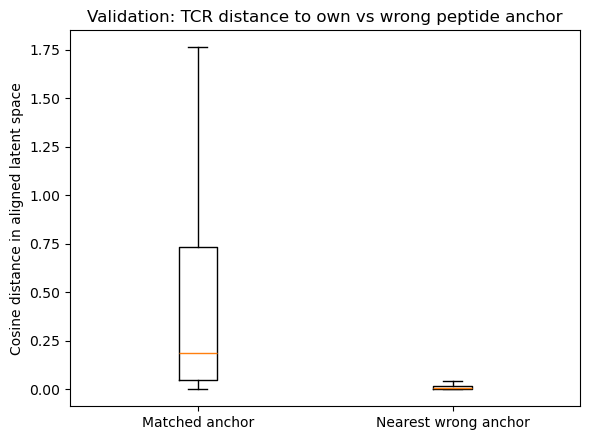

/tmp/ipykernel_1151740/3607379274.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


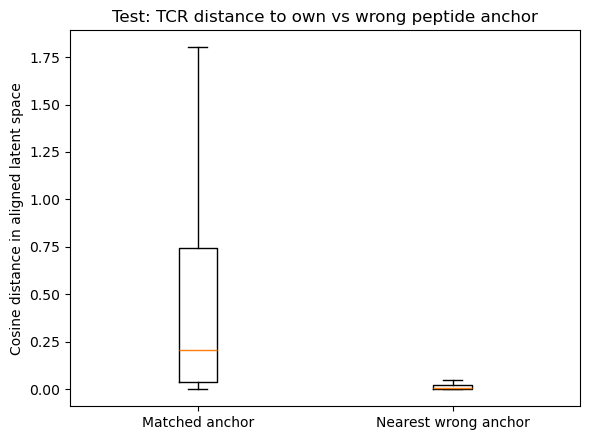

Validation stats: {'n_points': 1600, 'n_groups': 56, 'own_mean': 0.4793709153695045, 'own_median': 0.18734554233086642, 'nearest_wrong_mean': 0.04305619554756295, 'nearest_wrong_median': 0.006404285850152902, 'mannwhitney_u': 2205863.5, 'p_value_less': 1.0}
Test stats: {'n_points': 1809, 'n_groups': 62, 'own_mean': 0.48741230039353983, 'own_median': 0.20511664996810985, 'nearest_wrong_mean': 0.030908822636535823, 'nearest_wrong_median': 0.0074850440791643935, 'mannwhitney_u': 2820597.5, 'p_value_less': 1.0}


In [25]:
val_own, val_wrong, val_anchor_stats = own_anchor_vs_other_anchor_analysis(
    val_embs, val_meta, group_col="pmhc_id", min_count=3
)
test_own, test_wrong, test_anchor_stats = own_anchor_vs_other_anchor_analysis(
    test_embs, test_meta, group_col="pmhc_id", min_count=3
)

plot_own_vs_wrong_anchor(val_own, val_wrong, "Validation")
plot_own_vs_wrong_anchor(test_own, test_wrong, "Test")

print("Validation stats:", val_anchor_stats)
print("Test stats:", test_anchor_stats)